# Seq2Seq vs Seq2Seq+Attention 비교
- 테스트 : 숫자 시퀀스 뒤집기 (e.g. [5,3,7] → [7,3,5])

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## 1. 테스트 데이터 생성

In [2]:
VOCAB = 12   # 0=PAD  1=SOS  2=EOS  3~11=숫자토큰
PAD, SOS, EOS = 0, 1, 2

def make_data(n=2000, seed=42):
    random.seed(seed)
    pairs = []
    for _ in range(n):
        seq = [random.randint(3, VOCAB-1) for _ in range(random.randint(5, 10))]
        pairs.append((seq + [EOS], [SOS] + seq[::-1] + [EOS]))
    return pairs

def collate(batch):
    srcs, trgs = zip(*batch)
    ms = max(len(s) for s in srcs); mt = max(len(t) for t in trgs)
    return (torch.tensor([s+[PAD]*(ms-len(s)) for s in srcs]),
            torch.tensor([t+[PAD]*(mt-len(t)) for t in trgs]))

all_data   = make_data(2000)
train_data = all_data[:1600]
val_data   = all_data[1600:1800]
test_data  = all_data[1800:]
print(f'train={len(train_data)} val={len(val_data)} test={len(test_data)}')
print('src 샘플:', train_data[0][0])
print('trg 샘플:', train_data[0][1])


train=1600 val=200 test=200
src 샘플: [4, 3, 7, 6, 6, 5, 4, 11, 4, 9, 2]
trg 샘플: [1, 9, 4, 11, 4, 5, 6, 6, 7, 3, 4, 2]


## 2. 모델 정의

In [ ]:
# ── 기본 Seq2Seq (context vector 하나만 전달) ──
class Encoder(nn.Module):
    def __init__(self, vocab, emb, hid):
        super().__init__()
        self.embed = nn.Embedding(vocab, emb, padding_idx=PAD)
        self.rnn   = nn.GRU(emb, hid, batch_first=True)
    def forward(self, src):
        _, h = self.rnn(self.embed(src))
        return h  # (1, B, hid) 마지막 hidden만

class Decoder(nn.Module):
    def __init__(self, vocab, emb, hid):
        super().__init__()
        self.embed = nn.Embedding(vocab, emb, padding_idx=PAD)
        self.rnn   = nn.GRU(emb, hid, batch_first=True)
        self.fc    = nn.Linear(hid, vocab)
    def forward(self, tok, h):
        out, h = self.rnn(self.embed(tok.unsqueeze(1)), h)
        return self.fc(out.squeeze(1)), h

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.enc = enc; self.dec = dec
    def forward(self, src, trg, tf=0.5):
        B, T = trg.shape
        h = self.enc(src)
        inp = trg[:, 0]
        outs = torch.zeros(B, T, self.dec.fc.out_features).to(src.device)
        for t in range(1, T):
            pred, h = self.dec(inp, h)
            outs[:, t] = pred
            inp = trg[:, t] if random.random() < tf else pred.argmax(1)
        return outs


In [4]:
# ── Seq2Seq + Bahdanau Attention (매 스텝 소스 전체 참조) ──
class AttnEncoder(nn.Module):
    def __init__(self, vocab, emb, hid):
        super().__init__()
        self.embed = nn.Embedding(vocab, emb, padding_idx=PAD)
        self.rnn   = nn.GRU(emb, hid, batch_first=True)
    def forward(self, src):
        enc_outs, h = self.rnn(self.embed(src))
        return enc_outs, h  # 전체 hidden 보존 ← Vanilla와의 핵심 차이

class Attention(nn.Module):
    def __init__(self, hid):
        super().__init__()
        self.W = nn.Linear(hid * 2, hid)
        self.v = nn.Linear(hid, 1, bias=False)
    def forward(self, h, enc_outs):
        src_len = enc_outs.size(1)
        h_rep   = h.permute(1,0,2).repeat(1, src_len, 1)
        energy  = self.v(torch.tanh(self.W(torch.cat([h_rep, enc_outs], dim=2))))
        return F.softmax(energy.squeeze(2), dim=1)  # (B, src_len)

class AttnDecoder(nn.Module):
    def __init__(self, vocab, emb, hid):
        super().__init__()
        self.embed = nn.Embedding(vocab, emb, padding_idx=PAD)
        self.attn  = Attention(hid)
        self.rnn   = nn.GRU(emb + hid, hid, batch_first=True)
        self.fc    = nn.Linear(hid * 2, vocab)
    def forward(self, tok, h, enc_outs):
        emb     = self.embed(tok.unsqueeze(1))
        context = torch.bmm(self.attn(h, enc_outs).unsqueeze(1), enc_outs)
        out, h  = self.rnn(torch.cat([emb, context], dim=2), h)
        return self.fc(torch.cat([out, context], dim=2).squeeze(1)), h

class Seq2SeqAttn(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.enc = enc; self.dec = dec
    def forward(self, src, trg, tf=0.5):
        B, T = trg.shape
        enc_outs, h = self.enc(src)
        inp = trg[:, 0]
        outs = torch.zeros(B, T, self.dec.fc.out_features).to(src.device)
        for t in range(1, T):
            pred, h = self.dec(inp, h, enc_outs)  # 매 스텝 attention
            outs[:, t] = pred
            inp = trg[:, t] if random.random() < tf else pred.argmax(1)
        return outs


## 3. 하이퍼파라미터 튜닝

In [5]:
SEARCH_SPACE = {
    'emb': [32, 64],
    'hid': [64, 128],
    'lr' : [1e-3, 5e-4],
}
random.seed(0)
HP_CONFIGS = [{'emb': random.choice(SEARCH_SPACE['emb']),
               'hid': random.choice(SEARCH_SPACE['hid']),
               'lr' : random.choice(SEARCH_SPACE['lr'])}
              for _ in range(3)]
print('탐색 설정:')
for i, c in enumerate(HP_CONFIGS): print(f'  Config {i}: {c}')


탐색 설정:
  Config 0: {'emb': 64, 'hid': 128, 'lr': 0.001}
  Config 1: {'emb': 64, 'hid': 128, 'lr': 0.0005}
  Config 2: {'emb': 64, 'hid': 128, 'lr': 0.0005}


## 4. 학습 및 결과 비교

In [6]:
EPOCHS    = 20
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

def make_loader(data, bs=64, shuffle=True):
    return DataLoader(data, batch_size=bs, shuffle=shuffle, collate_fn=collate)

def run_epoch(model, loader, opt=None):
    model.train() if opt else model.eval()
    total = 0
    ctx = torch.enable_grad() if opt else torch.no_grad()
    with ctx:
        for src, trg in loader:
            src, trg = src.to(device), trg.to(device)
            out  = model(src, trg, tf=0.5 if opt else 0.0)
            loss = criterion(out[:,1:].reshape(-1, out.shape[-1]), trg[:,1:].reshape(-1))
            if opt:
                opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
    return total / len(loader)

# ── HP Search: 5 epoch으로 빠르게 비교 ──
def search_hp(model_cls, enc_cls, dec_cls):
    best_val, best_cfg = float('inf'), None
    tr_ld = make_loader(train_data)
    vl_ld = make_loader(val_data, shuffle=False)
    for cfg in HP_CONFIGS:
        m = model_cls(enc_cls(VOCAB, cfg['emb'], cfg['hid']),
                      dec_cls(VOCAB, cfg['emb'], cfg['hid'])).to(device)
        opt = torch.optim.Adam(m.parameters(), lr=cfg['lr'])
        for _ in range(5): run_epoch(m, tr_ld, opt)
        v = run_epoch(m, vl_ld)
        print(f'  {cfg}  val={v:.4f}')
        if v < best_val: best_val, best_cfg = v, cfg
    print(f'  Best: {best_cfg}\n')
    return best_cfg

print('=== Vanilla HP Search ===')
best_v = search_hp(Seq2Seq, Encoder, Decoder)
print('=== Attention HP Search ===')
best_a = search_hp(Seq2SeqAttn, AttnEncoder, AttnDecoder)


=== Vanilla HP Search ===
  {'emb': 64, 'hid': 128, 'lr': 0.001}  val=1.4395
  {'emb': 64, 'hid': 128, 'lr': 0.0005}  val=1.6477
  {'emb': 64, 'hid': 128, 'lr': 0.0005}  val=1.6363
  Best: {'emb': 64, 'hid': 128, 'lr': 0.001}

=== Attention HP Search ===
  {'emb': 64, 'hid': 128, 'lr': 0.001}  val=0.0866
  {'emb': 64, 'hid': 128, 'lr': 0.0005}  val=0.7513
  {'emb': 64, 'hid': 128, 'lr': 0.0005}  val=0.6091
  Best: {'emb': 64, 'hid': 128, 'lr': 0.001}



In [7]:
# ── 최적 HP로 전체 학습 ──
def train_full(model_cls, enc_cls, dec_cls, hp, label):
    m = model_cls(enc_cls(VOCAB, hp['emb'], hp['hid']),
                  dec_cls(VOCAB, hp['emb'], hp['hid'])).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=hp['lr'])
    tr_ld = make_loader(train_data)
    vl_ld = make_loader(val_data, shuffle=False)
    trs, vls = [], []
    for ep in range(1, EPOCHS+1):
        trs.append(run_epoch(m, tr_ld, opt))
        vls.append(run_epoch(m, vl_ld))
        if ep % 5 == 0:
            print(f'[{label}] Ep {ep:2d} | train={trs[-1]:.4f} val={vls[-1]:.4f}')
    return m, trs, vls

model_v, tr_v, vl_v = train_full(Seq2Seq,     Encoder,     Decoder,     best_v, 'Vanilla')
model_a, tr_a, vl_a = train_full(Seq2SeqAttn, AttnEncoder, AttnDecoder, best_a, 'Attention')


[Vanilla] Ep  5 | train=1.4673 val=1.4708
[Vanilla] Ep 10 | train=1.0617 val=1.1158
[Vanilla] Ep 15 | train=0.7213 val=0.8491
[Vanilla] Ep 20 | train=0.5017 val=0.6666
[Attention] Ep  5 | train=0.2296 val=0.1382
[Attention] Ep 10 | train=0.0075 val=0.0085
[Attention] Ep 15 | train=0.0023 val=0.0033
[Attention] Ep 20 | train=0.0011 val=0.0017


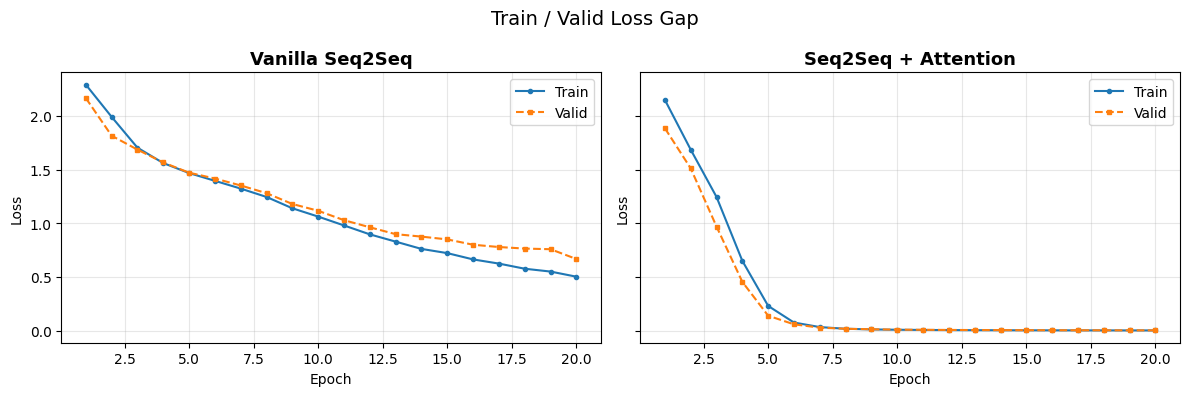

                 모델                              Best HP  Val Loss  Test Loss
    Vanilla Seq2Seq {'emb': 64, 'hid': 128, 'lr': 0.001}    0.6666     0.6907
Seq2Seq + Attention {'emb': 64, 'hid': 128, 'lr': 0.001}    0.0017     0.0012


In [15]:
# ── Loss 곡선 시각화 + 결과 테이블 ──
eps = range(1, EPOCHS+1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, tr, vl, title in zip(axes, [tr_v, tr_a], [vl_v, vl_a],
                               ['Vanilla Seq2Seq', 'Seq2Seq + Attention']):
    ax.plot(eps, tr, label='Train', marker='o', markersize=3)
    ax.plot(eps, vl, label='Valid', marker='s', markersize=3, ls='--')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Train / Valid Loss Gap', fontsize=14)
plt.tight_layout(); plt.show()

te_ld = make_loader(test_data, shuffle=False)
te_v  = run_epoch(model_v, te_ld)
te_a  = run_epoch(model_a, te_ld)
df = pd.DataFrame({
    '모델'     : ['Vanilla Seq2Seq', 'Seq2Seq + Attention'],
    'Best HP'  : [str(best_v), str(best_a)],
    'Val Loss' : [round(min(vl_v), 4), round(min(vl_a), 4)],
    'Test Loss': [round(te_v, 4),      round(te_a, 4)],
})
print(df.to_string(index=False))
